# Informe
## 1. Identificación de la base de datos

Se utilizó la MIT-BIH Arrhythmia Database, identificada en PhysioNet mediante el nombre mitdb. Esta base de datos contiene registros electrocardiográficos de pacientes evaluados para el estudio de alteraciones del ritmo cardiaco.



## 2. Identificación del registro

Se seleccionó el registro 101 de la MIT-BIH Arrhythmia Database. Este registro es diferente del registro 100 utilizado como ejemplo durante el desarrollo del laboratorio.



In [1]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "101"
CHANNEL = 1
DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_1.wav


In [5]:
!pip install uv

In [8]:
!uv pip install -q wfdb scipy pandas numpy matplotlib

In [11]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [10]:
# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.


## 3. Frecuencia de muestreo

La frecuencia de muestreo del registro 101 es de 360 Hz. Esto significa que el sistema registra 360 muestras de la señal ECG por cada segundo.

In [13]:
# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)



INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos


## 4. Canal seleccionado

Se seleccionó el canal 1, denominado V1. Este canal representa una derivación II modificada del electrocardiograma y permite observar la actividad eléctrica cardiaca, especialmente los complejos QRS.

In [14]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 1
Nombre            : V1


In [15]:
# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: V1
Unidad: mV

Primeras 10 muestras:
[-0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.16  -0.15  -0.145]


In [16]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")



Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos


## 5. Duración analizada

Se analizaron los primeros 10 segundos del registro. Debido a que la frecuencia de muestreo es de 360 Hz, el segmento analizado contiene 3600 muestras.

In [17]:
# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


## 6. Descripción de las gráficas

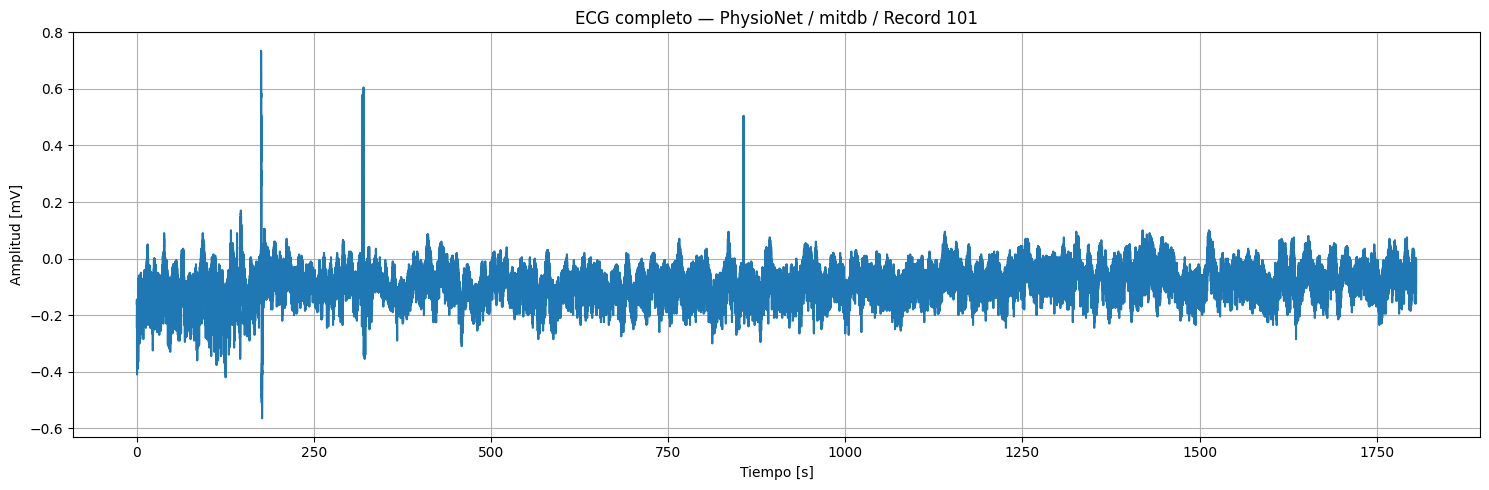

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO DE 101
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

La primera gráfica presenta la señal ECG completa del canal MLII. Debido a que se está visualizando todo el registro, los latidos aparecen muy juntos y no se puede distinguir individualmente las ondas del ECG. Se observan algunos picos de gran amplitud que pueden deberse a ruidos.  

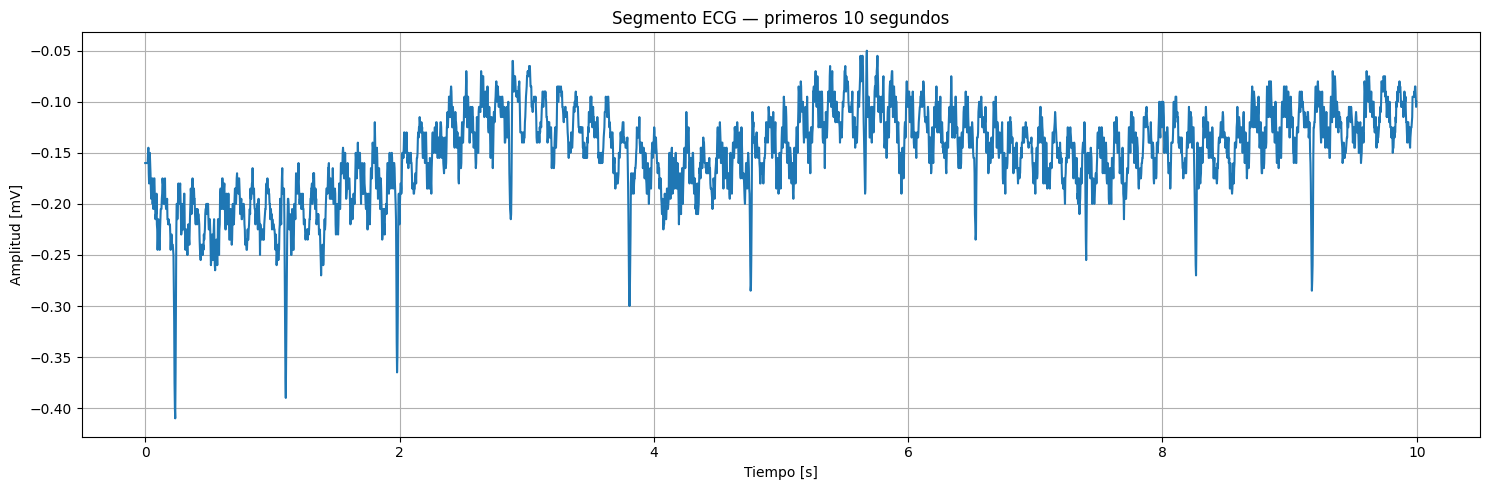

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

La segunda muestra detalladamente los primeros 10 segundos de la señal.Se observa picos negativos que se estan repitiendo de manera periódica, pueden corresponder a los complejos QRS. Esta ampliación permite analizar mejor la señal que cuando observábamos los 30 minutos completos

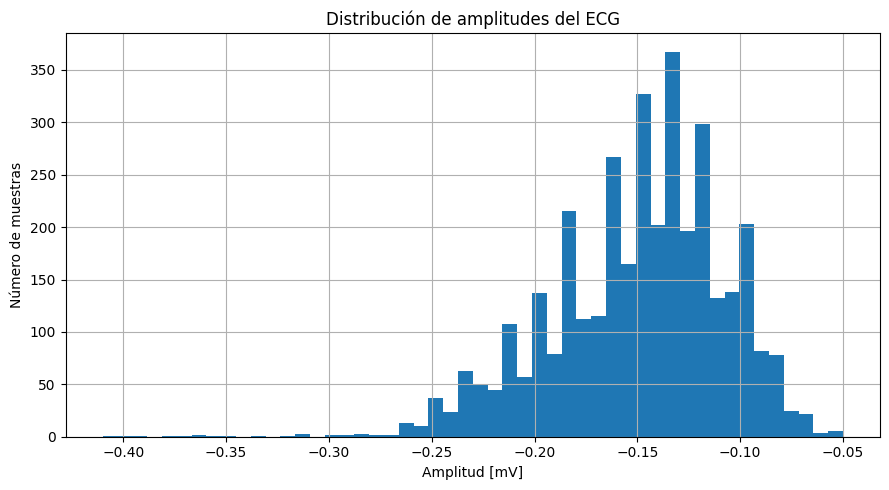

In [ ]:


# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

La tercera corresponde al histograma de amplitudes. Se puede observar que la mayoría de las muestras se concentran alrededor de −0.15 a −0.10 mV, mientras que los valores más extremos, cercanos a −0.4 mV, aparecen con mucha menor frecuencia.

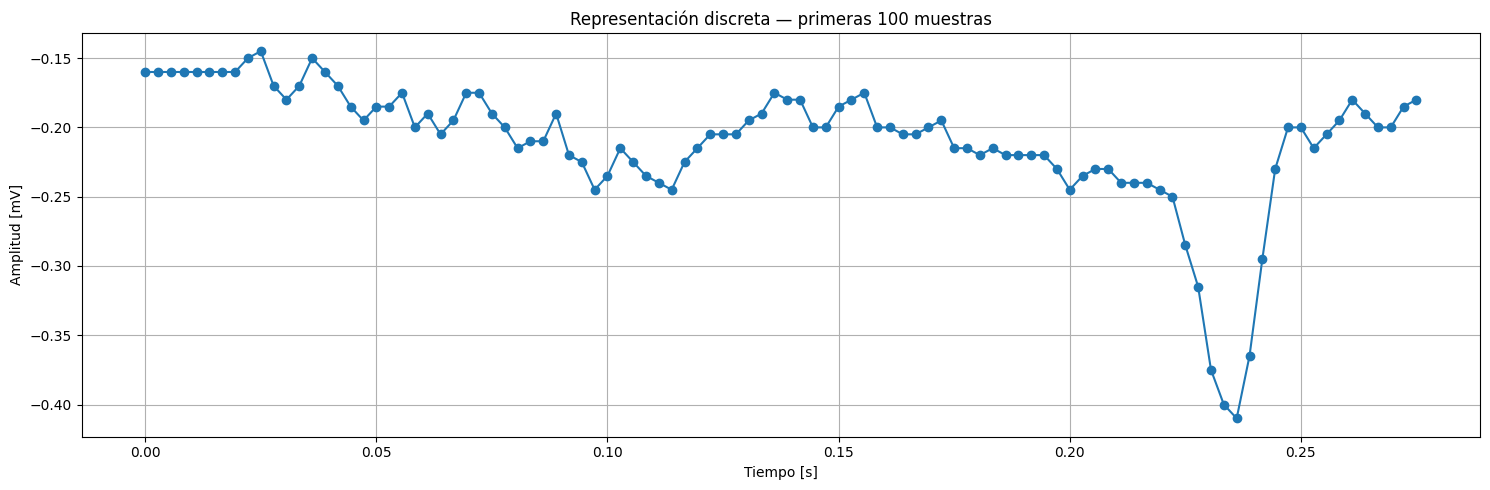

In [ ]:
# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()


La cuarta presenta la señal de forma discreta, mostrando individualmente las muestras adquiridas.





La representación discreta permite comprobar que la señal ECG almacenada digitalmente no es continua, sino que está formada por muestras adquiridas en instantes separados. La distancia temporal entre dos muestras consecutivas es:

$$ T_s=\frac{1}{360}=0.00278\text{ s} $$

Por lo tanto, se registra una muestra aproximadamente cada 2.78 milisegundos.

## 7. Estadisticas básicas

In [ ]:
# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.1499
Desviación estándar: 0.0428
Mínimo            : -0.4100
Máximo            : -0.0500
Rango             : 0.3600


## 8. Archivo WAV


In [18]:
# ============================================
# PREPARAR ECG PARA WAV - REGISTRO 2
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError(
        "La señal no puede normalizarse porque todos sus valores son cero."
    )

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")

Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -32767
Máximo int16    : 12587


In [19]:
# ============================================
# GUARDAR WAV - REGISTRO 2
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print("Archivo WAV generado correctamente:")
print(OUTPUT_WAV)

Archivo WAV generado correctamente:
ecg_record_101_channel_1.wav


In [20]:
# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)

In [21]:
# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Interpretación general de los resultados

En el segmento de 10 segundos del canal MLII se observa una señal ECG compuesta por variaciones periódicas de amplitud. Los cambios rápidos y de mayor amplitud corresponden principalmente a los complejos QRS, asociados con la despolarización ventricular. La media y la mediana describen el nivel central de la señal, mientras que la desviación estándar y la varianza representan su dispersión. El rango expresa la diferencia entre las amplitudes máxima y mínima, y el RMS representa el valor eficaz de la señal. Este análisis es descriptivo y no constituye por sí solo un diagnóstico clínico.


## 10. Conclusiones

Se logró cargar y analizar correctamente el registro 101 de la MIT-BIH Arrhythmia Database disponible en PhysioNet. Se identificaron sus canales y se seleccionó el canal MLII para analizar un segmento de 10 segundos, equivalente a 3600 muestras. Las representaciones temporal, estadística, discreta y mediante histograma permitieron estudiar diferentes características de la señal ECG. Finalmente, el segmento seleccionado fue normalizado y exportado correctamente en formato WAV. El procedimiento demuestra que las señales fisiológicas digitales pueden visualizarse, cuantificarse y convertirse a otros formatos para su posterior procesamiento.